# 07 — LGBM Walk-Forward Optimization (vtrain4)

Three critical mechanical fixes applied to vtrain3:

| # | Problem (vtrain3) | Root cause | Fix applied here |
|---|---|---|---|
| 1 | SL/TP evaluated on hourly **close** only | Backtester ignores intra-candle wicks | Pass `high`/`low`; check SL against `low` and TP against `high`; if both breached assume **SL hit first** (conservative) |
| 2 | Zero transaction costs | No fees or slippage modeled | **0.1 % per side** (0.2 % round-trip, conservative Binance taker) applied at entry and exit to notional |
| 3 | K-Fold internal val taken from **tail of full dataset** | `Xtr_k[-n_int:]` always selects late-2024 data regardless of fold | Internal val taken from the **n_int bars immediately preceding the embargo** of each fold, matching the temporal context being predicted |

Everything else (K=5 purged K-Fold on TrainVal, expanding-window WFO at 720 h, ATR-relative SL/TP, same LightGBM hyperparams) is unchanged from vtrain3.

In [1]:
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── Phase 1: Purged K-Fold on Train+Val ──────────────────────────────────────
K       = 5
EMBARGO = 168
KFOLD_INTERNAL_VAL_H  = 2500
EARLY_STOPPING_ROUNDS = 50

# ── Phase 2: Walk-Forward Optimization ───────────────────────────────────────
WFO_STEP_H         = 720
WFO_INTERNAL_VAL_H = 2500
WFO_PATIENCE       = 50

# ── FIX 2: Transaction cost ───────────────────────────────────────────────────
FEE_RATE = 0.001   # 0.1% per side → 0.2% round-trip (Binance taker, conservative)

# ── Optimisation ─────────────────────────────────────────────────────────────
OPTIMISE_METRIC = 'sharpe'
MIN_TRADES      = 30
TOP_N           = 20

# ── LightGBM hyperparameters (identical to vtrain3) ─────────────────────────
LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'n_estimators':      1000,
    'learning_rate':     0.02,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

# ── Grid ─────────────────────────────────────────────────────────────────────
# With fees, fewer higher-conviction trades are rewarded.
# Upper threshold range extended slightly vs vtrain3.
GRID = {
    'long_threshold':    [0.54, 0.56, 0.58, 0.60, 0.62],
    'short_threshold':   [0.38, 0.40, 0.42, 0.44, 0.46],
    'sl_atr_multiplier': [1.5, 2.0, 2.5],
    'tp_atr_multiplier': [1.5, 2.0, 3.0],
    'min_sl':            [0.010, 0.015, 0.020],
    'min_hold':          [4, 6, 8, 12],   # 12h added: longer holds amortise fees
    'max_hold':          [24, 48],
    'cooldown':          [2, 3],
}

In [2]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_lgbm'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'MODELS_DIR : {MODELS_DIR}')

REPO_ROOT  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


In [3]:
# ── Feature parquet (close, atr_14_pct, 195 features, label) ─────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

# ── FIX 1: Load high/low from raw parquet for intra-candle SL/TP ─────────────
raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')

missing_hl = feat_df[['high', 'low']].isna().sum()
print(f'high/low NaN after join: {missing_hl.to_dict()}')
feat_df = feat_df.dropna(subset=['high', 'low'])

# ── Calendar splits ───────────────────────────────────────────────────────────
train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)
trainval_df = pd.concat([train_df, val_df]).sort_index()

selected_features = pd.read_csv(
    MODELS_DIR / 'lgbm_features.csv', header=None
)[0].tolist()

X_tv   = trainval_df[selected_features].values
y_tv   = trainval_df['label'].values
X_test = test_df[selected_features].values
y_test = test_df['label'].values

# Arrays needed by the backtest engine
def _arr(df, col): return df[col].values.astype(np.float64)

tv_close = _arr(trainval_df, 'close')
tv_high  = _arr(trainval_df, 'high')
tv_low   = _arr(trainval_df, 'low')
tv_atr   = _arr(trainval_df, 'atr_14_pct')
tv_index = trainval_df.index

test_close = _arr(test_df, 'close')
test_high  = _arr(test_df, 'high')
test_low   = _arr(test_df, 'low')
test_atr   = _arr(test_df, 'atr_14_pct')
test_index = test_df.index

n_wfo_steps = int(np.ceil(len(test_df) / WFO_STEP_H))
print(f'TrainVal : {len(trainval_df):>7,}  {trainval_df.index[0].date()} → {trainval_df.index[-1].date()}')
print(f'Test     : {len(test_df):>7,}  {test_df.index[0].date()} → {test_df.index[-1].date()}')
print(f'Features : {len(selected_features)}')
print(f'WFO steps: {n_wfo_steps} × {WFO_STEP_H}h  (monthly retrain)')

high/low NaN after join: {'high': 0, 'low': 0}
TrainVal :  61,118  2017-11-15 → 2024-11-10
Test     :  13,248  2024-11-10 → 2026-05-16
Features : 50
WFO steps: 19 × 720h  (monthly retrain)


## Phase 1 — Purged K-Fold OOS probabilities (Train + Val)

**Fix 3 applied here.**

For fold `k` testing rows `[fold_start, fold_end)`, the internal validation window used for
early stopping is now carved from the **`KFOLD_INTERNAL_VAL_H` bars immediately before the
fold's embargo zone** (`emb_start - n_int : emb_start`).  This ensures the loss curve that
guides early stopping comes from the same market epoch being predicted, not from the
unrelated end of the full dataset (late 2024).

**Edge case — fold 1 (no data before embargo):** falls back to the first `min(KFOLD_INTERNAL_VAL_H, 1000)` bars after the embargo end, which is still temporally adjacent to the fold period.

In [4]:
n_tv      = len(trainval_df)
fold_size = n_tv // K
oos_probs_tv = np.full(n_tv, np.nan)

t0 = time.perf_counter()
for k in range(K):
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else n_tv

    emb_start = max(0, fold_start - EMBARGO)
    emb_end   = min(n_tv, fold_end + EMBARGO)

    # ── FIX 3: internal val = n_int bars immediately before embargo zone ─────
    if emb_start >= 200:   # enough pre-fold history
        n_int     = min(KFOLD_INTERNAL_VAL_H, emb_start)
        int_end   = emb_start
        int_start = emb_start - n_int
        source    = f'pre-fold  [{int_start}, {int_end})'
    else:
        # Edge case: fold 1 or very early fold — use first chunk after embargo
        n_int     = min(KFOLD_INTERNAL_VAL_H, 1000)
        int_start = emb_end
        int_end   = min(n_tv, emb_end + n_int)
        n_int     = int_end - int_start
        source    = f'post-emb  [{int_start}, {int_end})'

    # ── Training mask: exclude fold+embargo AND internal val region ──────────
    mask = np.ones(n_tv, dtype=bool)
    mask[emb_start:emb_end]   = False  # fold + embargo
    mask[int_start:int_end]   = False  # internal val (must not be in train)

    Xtr_fit = X_tv[mask]
    ytr_fit = y_tv[mask]
    Xvl_int = X_tv[int_start:int_end]
    yvl_int = y_tv[int_start:int_end]

    ds_tr = lgb.Dataset(Xtr_fit, label=ytr_fit, feature_name=selected_features)
    ds_vl = lgb.Dataset(Xvl_int, label=yvl_int,
                         feature_name=selected_features, reference=ds_tr)

    fold_model = lgb.train(
        LGB_PARAMS, ds_tr,
        valid_sets=[ds_tr, ds_vl],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    fold_pred = fold_model.predict(X_tv[fold_start:fold_end])
    oos_probs_tv[fold_start:fold_end] = fold_pred

    print(
        f'Fold {k+1}/{K}  '
        f'train={mask.sum():,}  int_val={n_int:,} ({source})  '
        f'fold={fold_end-fold_start:,}  '
        f'best_iter={fold_model.best_iteration}  '
        f'prob=[{fold_pred.min():.3f}, {fold_pred.max():.3f}]'
    )
    del fold_model

print(f'\nK-Fold done in {time.perf_counter()-t0:.1f}s  |  '
      f'coverage={np.isfinite(oos_probs_tv).sum():,}/{n_tv:,}')

Fold 1/5  train=47,727  int_val=1,000 (post-emb  [12391, 13391))  fold=12,223  best_iter=98  prob=[0.355, 0.679]
Fold 2/5  train=46,059  int_val=2,500 (pre-fold  [9555, 12055))  fold=12,223  best_iter=386  prob=[0.252, 0.809]
Fold 3/5  train=46,059  int_val=2,500 (pre-fold  [21778, 24278))  fold=12,223  best_iter=188  prob=[0.286, 0.723]
Fold 4/5  train=46,059  int_val=2,500 (pre-fold  [34001, 36501))  fold=12,223  best_iter=100  prob=[0.352, 0.693]
Fold 5/5  train=46,224  int_val=2,500 (pre-fold  [46224, 48724))  fold=12,226  best_iter=372  prob=[0.264, 0.746]

K-Fold done in 9.8s  |  coverage=61,118/61,118


OOS probs  — mean=0.5141  std=0.0668  range=[0.2517, 0.8091]
OOS AUC    — 0.5766


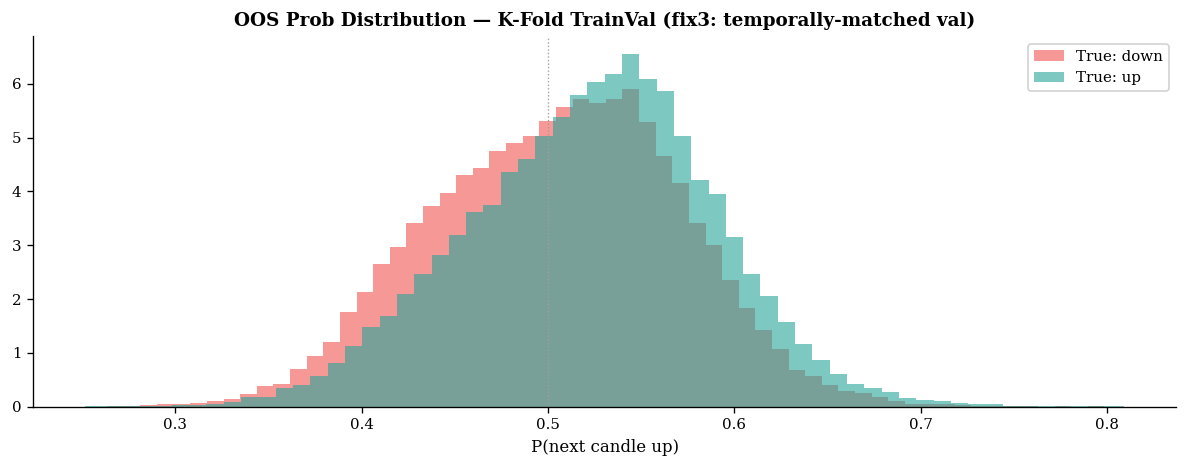

In [5]:
valid_mask = np.isfinite(oos_probs_tv)
oos_index  = trainval_df.index[valid_mask]
oos_probs  = oos_probs_tv[valid_mask]
oos_close  = tv_close[valid_mask]
oos_high   = tv_high[valid_mask]
oos_low    = tv_low[valid_mask]
oos_atr    = tv_atr[valid_mask]
oos_labels = trainval_df['label'].values[valid_mask]

print(f'OOS probs  — mean={oos_probs.mean():.4f}  std={oos_probs.std():.4f}'
      f'  range=[{oos_probs.min():.4f}, {oos_probs.max():.4f}]')
print(f'OOS AUC    — {roc_auc_score(oos_labels, oos_probs):.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oos_probs[oos_labels == 0], bins=60, alpha=0.6, color=RED,
        label='True: down', density=True)
ax.hist(oos_probs[oos_labels == 1], bins=60, alpha=0.6, color=GREEN,
        label='True: up',   density=True)
ax.axvline(0.5, color=GREY, ls=':', lw=0.8)
ax.set_xlabel('P(next candle up)')
ax.set_title('OOS Prob Distribution — K-Fold TrainVal (fix3: temporally-matched val)',
             fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'oos_prob_distribution_vtrain4.png')
plt.show()

## Phase 1 — Grid Search on OOS Probabilities

**Fix 1 (intra-candle SL/TP) and Fix 2 (fees) are applied inside `run_backtest`.**

### Fix 1 — Intra-candle SL/TP logic
For each bar, `high` and `low` are checked **before** the close price is used:
- **Long:** if `low ≤ sl_price` → SL hit (exit at `sl_price`); else if `high ≥ tp_price` → TP hit.
- **Short:** if `high ≥ sl_price` → SL hit; else if `low ≤ tp_price` → TP hit.
- If **both** SL and TP are breached within the same candle, **SL is assumed** (conservative;
  we cannot know intra-bar tick sequence).
- Confidence and max-hold exits remain close-based (signal evaluated at candle close).

### Fix 2 — Transaction fees
A flat `FEE_RATE = 0.001` (0.1 %) is deducted on both entry and exit:
```
Long entry : units = cash * (1 - fee) / entry_px
Long exit  : cash  = units * exit_px * (1 - fee)
Short entry: entry_cash = cash * (1 - fee)
Short exit : cash  = entry_cash * (1 + pnl_gross) * (1 - fee)
```
With 897 trades (vtrain3) × 0.2 % round-trip ≈ 179 pp gross drag.
The grid search on fee-inclusive OOS equity will naturally select **fewer, higher-conviction**
trades to amortise costs.

In [6]:
def run_backtest(probs, close_arr, high_arr, low_arr, atr_arr, sig_index, params,
                 fee=FEE_RATE):
    """Backtest with intra-candle SL/TP (Fix 1) and transaction fees (Fix 2)."""
    long_thr    = params['long_threshold']
    short_thr   = params['short_threshold']
    exit_long   = 1 - long_thr
    exit_short  = 1 - short_thr
    sl_atr_mult = params['sl_atr_multiplier']
    tp_atr_mult = params['tp_atr_multiplier']
    min_sl      = params['min_sl']
    min_hold    = params['min_hold']
    max_hold    = params['max_hold']
    cooldown_n  = params['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0
    dynamic_sl = 0.0; dynamic_tp = 0.0
    hold_count = 0; cooldown = 0

    equity_curve = [1.0]
    trade_log    = []

    n = len(close_arr)
    for i in range(n):
        ts   = sig_index[i]
        px   = close_arr[i]
        hi   = high_arr[i]
        lo   = low_arr[i]
        conf = probs[i]
        atr_pct = atr_arr[i]

        if cooldown > 0:
            cooldown -= 1

        reason   = None
        exit_px  = None
        pnl      = None

        if in_pos:
            hold_count += 1

            if direction == 'long':
                sl_price = entry_px * (1.0 - dynamic_sl)
                tp_price = entry_px * (1.0 + dynamic_tp)

                # FIX 1: check intra-candle wicks; SL first (conservative)
                if lo <= sl_price:
                    reason  = 'sl'
                    exit_px = sl_price
                    pnl     = -dynamic_sl
                elif hi >= tp_price:
                    reason  = 'tp'
                    exit_px = tp_price
                    pnl     = dynamic_tp
                elif hold_count >= max_hold:
                    reason  = 'max_hold'
                    exit_px = px
                    pnl     = (px - entry_px) / entry_px
                elif hold_count >= min_hold and conf < exit_long:
                    reason  = 'conf'
                    exit_px = px
                    pnl     = (px - entry_px) / entry_px

                if reason:
                    # FIX 2: exit fee on long
                    cash  = units * exit_px * (1.0 - fee)
                    units = 0.0

            elif direction == 'short':
                sl_price = entry_px * (1.0 + dynamic_sl)
                tp_price = entry_px * (1.0 - dynamic_tp)

                # FIX 1: check intra-candle wicks; SL first (conservative)
                if hi >= sl_price:
                    reason  = 'sl'
                    exit_px = sl_price
                    pnl     = -dynamic_sl
                elif lo <= tp_price:
                    reason  = 'tp'
                    exit_px = tp_price
                    pnl     = dynamic_tp
                elif hold_count >= max_hold:
                    reason  = 'max_hold'
                    exit_px = px
                    pnl     = (entry_px - px) / entry_px
                elif hold_count >= min_hold and conf > exit_short:
                    reason  = 'conf'
                    exit_px = px
                    pnl     = (entry_px - px) / entry_px

                if reason:
                    # FIX 2: exit fee on short
                    gross_pnl = (entry_px - exit_px) / entry_px
                    cash  = entry_cash * (1.0 + gross_pnl) * (1.0 - fee)
                    units = 0.0

            if reason:
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None
                hold_count = 0; cooldown = cooldown_n

        if not in_pos and cooldown == 0:
            dynamic_sl = max(sl_atr_mult * atr_pct, min_sl)
            dynamic_tp = tp_atr_mult * atr_pct

            if conf >= long_thr:
                # FIX 2: entry fee on long
                units = cash * (1.0 - fee) / px
                cash  = 0.0
                in_pos = True; direction = 'long'
                entry_px = px; hold_count = 0
            elif conf <= short_thr:
                # FIX 2: entry fee on short
                entry_cash = cash * (1.0 - fee)
                units = entry_cash / px
                in_pos = True; direction = 'short'
                entry_px = px; hold_count = 0

        if in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1.0 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    # Force-close at end
    if in_pos:
        px = close_arr[-1]
        if direction == 'long':
            gross_pnl = (px - entry_px) / entry_px
            cash = units * px * (1.0 - fee)
        else:
            gross_pnl = (entry_px - px) / entry_px
            cash = entry_cash * (1.0 + gross_pnl) * (1.0 - fee)
        pnl = gross_pnl
        trade_log.append({'direction': direction, 'pnl_pct': pnl,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    return np.array(equity_curve[1:]), pd.DataFrame(trade_log)


def score_equity(equity_arr, trades_df, metric):
    if trades_df.empty:
        return -np.inf
    eq  = equity_arr
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    ann = 24 * 365
    if metric == 'sharpe':
        return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))
    if metric == 'total_return':
        return float(eq[-1] - 1)
    if metric == 'calmar':
        ar  = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ar / (abs(mdd) + 1e-6)
    if metric == 'win_rate':
        return float((trades_df['pnl_pct'] > 0).mean())
    if metric == 'profit_factor':
        g = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        l = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(g / (l + 1e-6))
    return -np.inf


print(f'run_backtest() defined  (intra-candle SL/TP + {FEE_RATE*100:.1f}% fee per side).')

run_backtest() defined  (intra-candle SL/TP + 0.1% fee per side).


In [7]:
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))

valid_combos = [
    dict(zip(keys, v)) for v in combos
    if v[0] > 0.5
    and v[1] < 0.5
    and v[0] - (1 - v[1]) >= 0.02
]
print(f'Total combos : {len(combos):,}')
print(f'Valid combos : {len(valid_combos):,}')
print(f'Optimising   : {OPTIMISE_METRIC}')

results = []
for params in tqdm(valid_combos, desc='Grid search (OOS)'):
    eq, tdf = run_backtest(oos_probs, oos_close, oos_high, oos_low, oos_atr,
                           oos_index, params)
    if len(tdf) < MIN_TRADES:
        continue

    s   = score_equity(eq, tdf, OPTIMISE_METRIC)
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)

    results.append({
        **params,
        'score':        s,
        'total_return': float(eq[-1] - 1),
        'sharpe':       float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)),
        'max_dd':       float(((eq - pk) / (pk + 1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct'] > 0).mean()),
        'n_long':       int((tdf['direction'] == 'long').sum()),
        'n_short':      int((tdf['direction'] == 'short').sum()),
        'n_sl':         int((tdf['reason'] == 'sl').sum()),
        'n_tp':         int((tdf['reason'] == 'tp').sum()),
        'n_conf':       int((tdf['reason'] == 'conf').sum()),
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid results : {len(results_df):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}   : {results_df["score"].iloc[0]:.4f}')
    print(f'Worst {OPTIMISE_METRIC}  : {results_df["score"].iloc[-1]:.4f}')

Total combos : 10,800
Valid combos : 3,456
Optimising   : sharpe


Grid search (OOS): 100%|██████████| 3456/3456 [06:19<00:00,  9.12it/s]


Valid results : 3,456
Best sharpe   : -0.0146
Worst sharpe  : -2.4517


In [8]:
display_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'long_threshold', 'short_threshold',
    'sl_atr_multiplier', 'tp_atr_multiplier', 'min_sl',
    'min_hold', 'max_hold', 'cooldown',
]
top = results_df[display_cols].head(TOP_N).copy()
top['total_return'] = top['total_return'].map('{:+.2%}'.format)
top['max_dd']       = top['max_dd'].map('{:.2%}'.format)
top['win_rate']     = top['win_rate'].map('{:.1%}'.format)
top['score']        = top['score'].map('{:.4f}'.format)
top['sharpe']       = top['sharpe'].map('{:.3f}'.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} by {OPTIMISE_METRIC}  (OOS K-Fold, intra-candle SL/TP, fee={FEE_RATE*100:.1f}%/side):\n')
print(top.to_string(index=True))
print(f'\n── Best config ──────────────────────────────────────────')
for k, v in best_params.items():
    print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')
print(f'  {"OOS Trades":<24}: {int(best["n_trades"])}')

Top 20 by sharpe  (OOS K-Fold, intra-candle SL/TP, fee=0.1%/side):

      score total_return  sharpe   max_dd win_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  sl_atr_multiplier  tp_atr_multiplier  min_sl  min_hold  max_hold  cooldown
0   -0.0146       -4.72%  -0.015  -81.21%    57.5%      2096    1049     1047   644   525            0.62              0.4                2.5                3.0   0.015         8        24         3
1   -0.0171       -5.46%  -0.017  -83.35%    59.9%      2219    1110     1109   645   488            0.62              0.4                2.5                3.0   0.015         4        24         3
2   -0.0229       -7.29%  -0.023  -81.43%    58.6%      2158    1086     1072   648   508            0.62              0.4                2.5                3.0   0.015         6        24         3
3   -0.0309       -9.37%  -0.031  -84.46%    64.3%      2324    1194     1130   699   926            0.62              0.4              

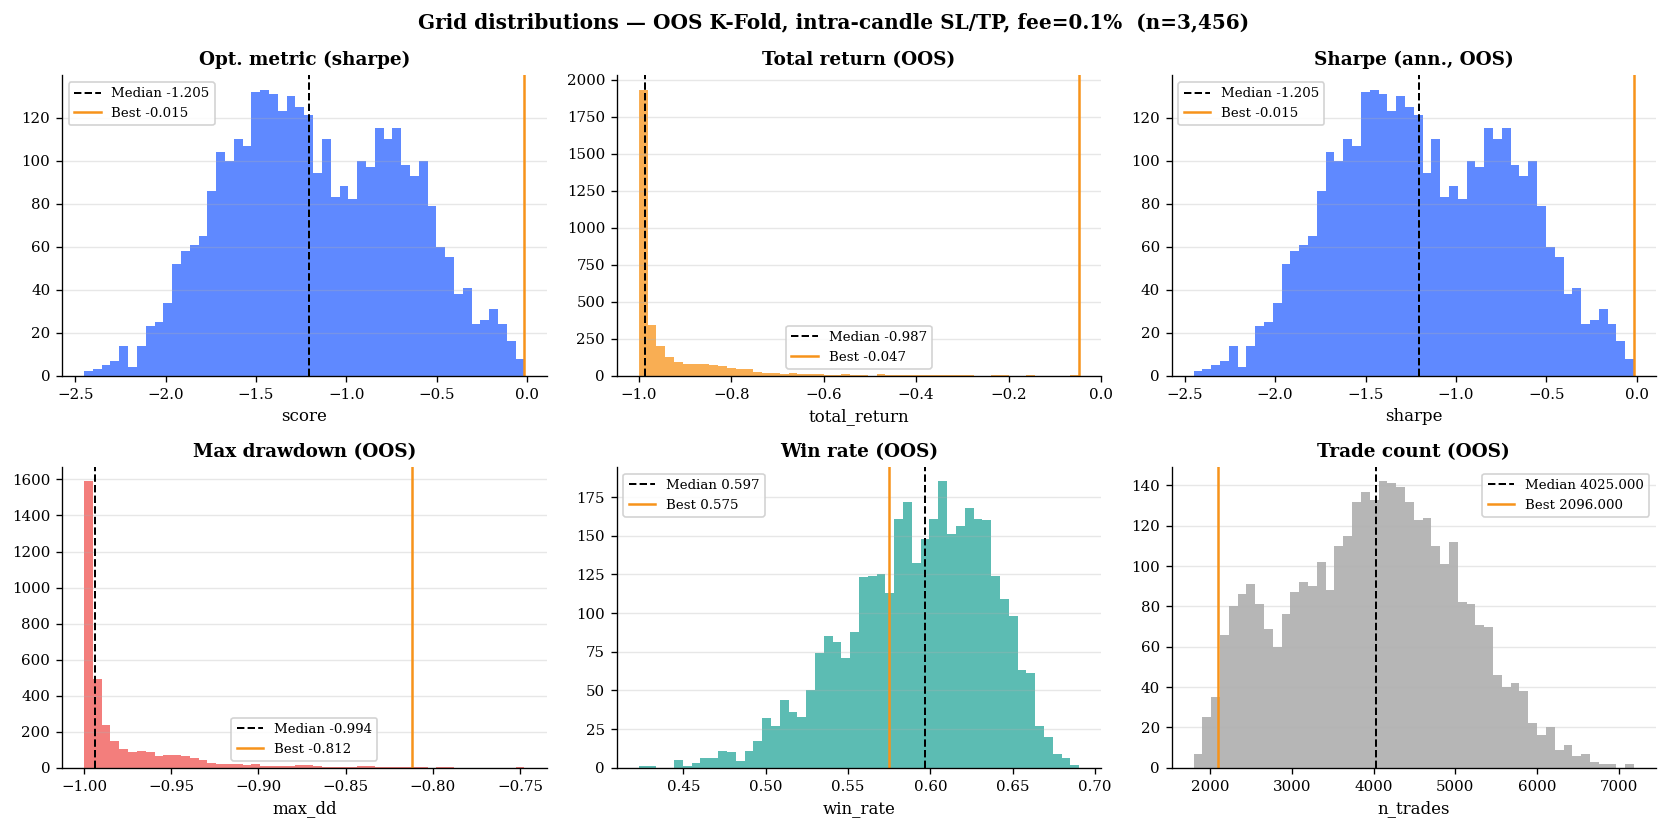

In [9]:
plot_cols = [
    ('score',        f'Opt. metric ({OPTIMISE_METRIC})', BLUE),
    ('total_return', 'Total return (OOS)',               ACCENT),
    ('sharpe',       'Sharpe (ann., OOS)',               BLUE),
    ('max_dd',       'Max drawdown (OOS)',               RED),
    ('win_rate',     'Win rate (OOS)',                   GREEN),
    ('n_trades',     'Trade count (OOS)',                GREY),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, title, color) in zip(axes.flat, plot_cols):
    data = results_df[col]
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='black', lw=1.2, ls='--',
               label=f'Median {data.median():.3f}')
    ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5, ls='-',
               label=f'Best {results_df[col].iloc[0]:.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.suptitle(
    f'Grid distributions — OOS K-Fold, intra-candle SL/TP, fee={FEE_RATE*100:.1f}%  '
    f'(n={len(results_df):,})',
    fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_distributions_vtrain4.png')
plt.show()

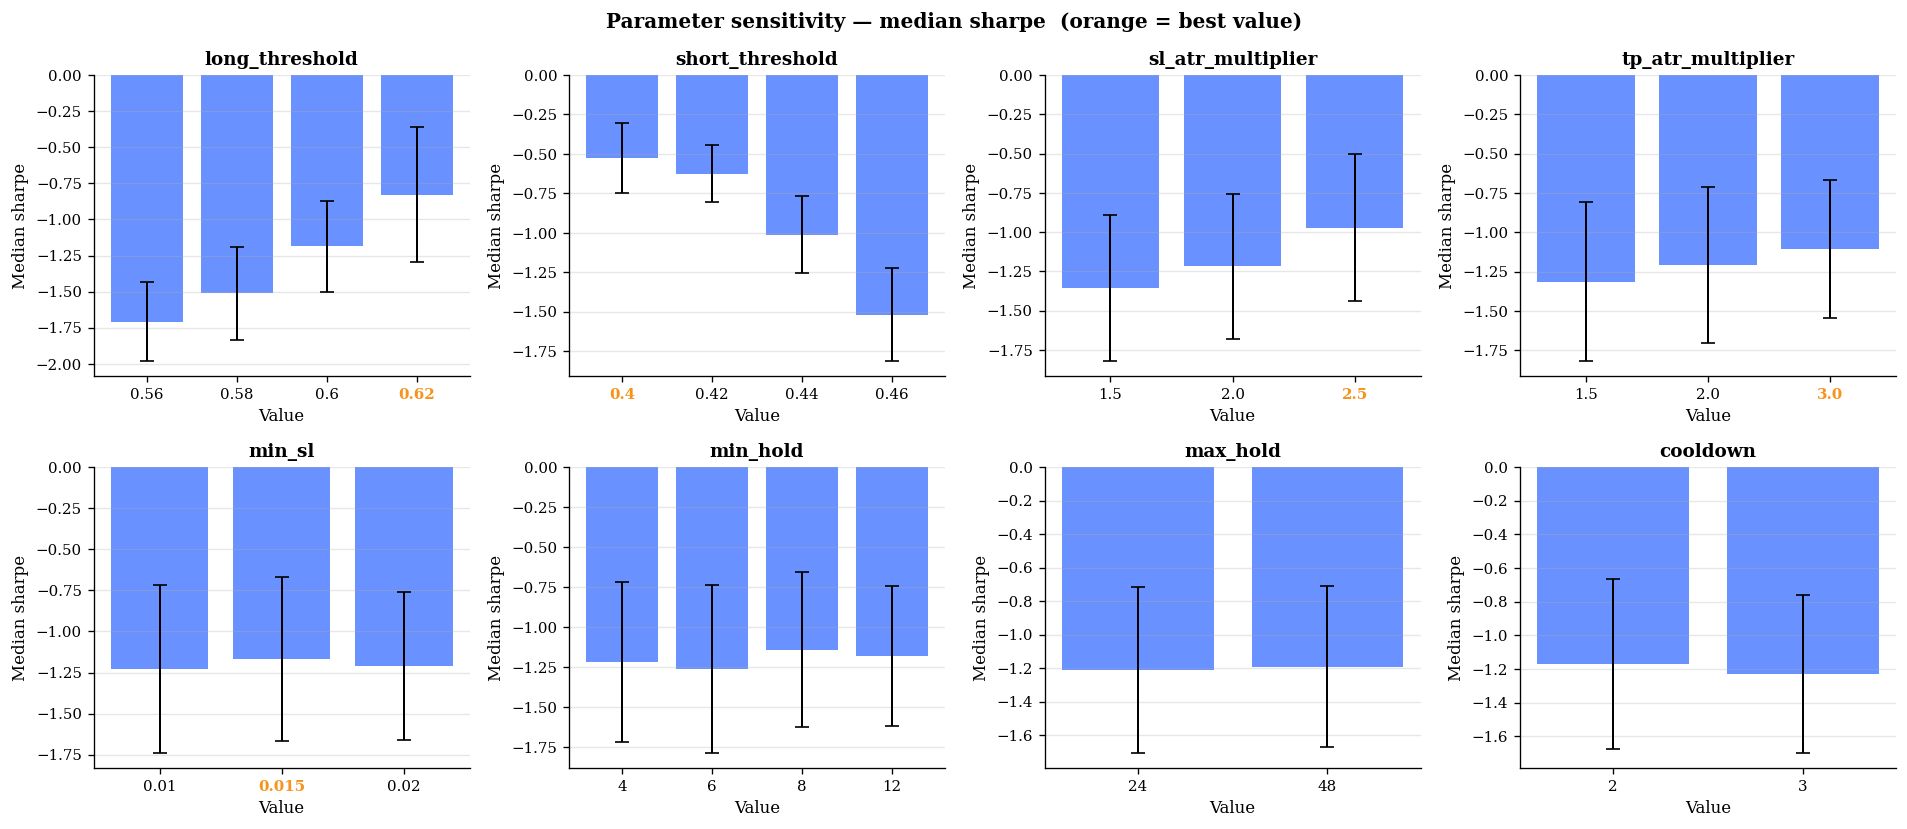

In [10]:
n_params = len(keys)
ncols = 4; nrows = int(np.ceil(n_params / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
for ax, param in zip(axes.flat, keys):
    grp = results_df.groupby(param)['score'].agg(['median', 'std']).reset_index()
    x   = grp[param].astype(str)
    ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
    ax.errorbar(x, grp['median'], yerr=grp['std'],
                fmt='none', color='black', capsize=4, lw=1.2)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
    ax.grid(axis='y', alpha=0.3)
    best_val = str(best[param])
    for tick in ax.get_xticklabels():
        if tick.get_text() == best_val:
            tick.set_color(ACCENT); tick.set_fontweight('bold')
for ax in axes.flat[n_params:]:
    ax.set_visible(False)
fig.suptitle(f'Parameter sensitivity — median {OPTIMISE_METRIC}  (orange = best value)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_sensitivity_vtrain4.png')
plt.show()

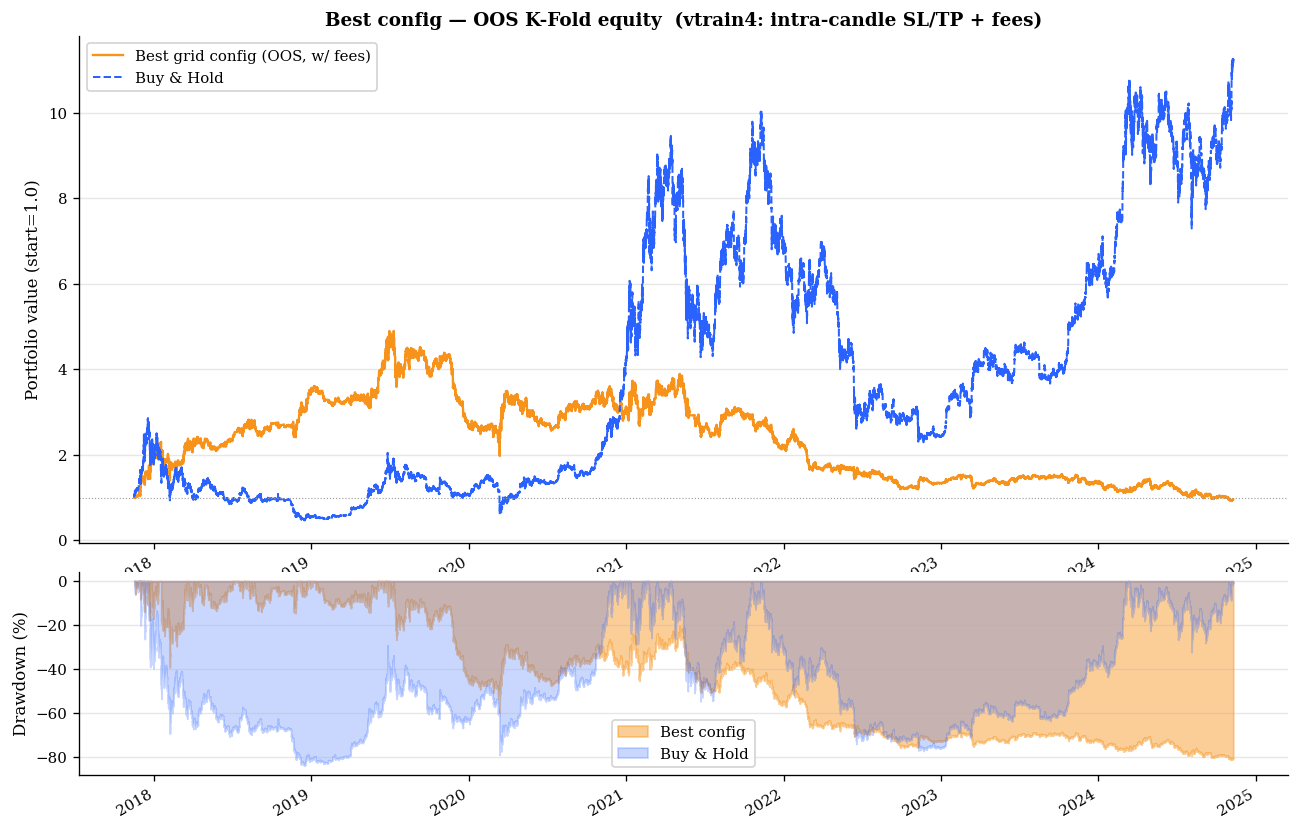

OOS K-Fold  |  Sharpe=-0.015  Return=-4.72%  MaxDD=-81.21%  Trades=2096


In [11]:
eq_oos, tdf_oos = run_backtest(oos_probs, oos_close, oos_high, oos_low, oos_atr,
                               oos_index, best_params)
bh_oos = oos_close / oos_close[0]

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
ax = axes[0]
ax.plot(oos_index, eq_oos,   color=ACCENT, lw=1.4, label='Best grid config (OOS, w/ fees)')
ax.plot(oos_index, bh_oos,   color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title('Best config — OOS K-Fold equity  (vtrain4: intra-candle SL/TP + fees)',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
pk_s = np.maximum.accumulate(eq_oos)
pk_b = np.maximum.accumulate(bh_oos)
ax.fill_between(oos_index, (eq_oos - pk_s) / (pk_s + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Best config')
ax.fill_between(oos_index, (bh_oos - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_oos_best_equity_vtrain4.png')
plt.show()

ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
print(f'OOS K-Fold  |  '
      f'Sharpe={ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
      f'Return={eq_oos[-1]-1:+.2%}  '
      f'MaxDD={((eq_oos-pk_oos)/(pk_oos+1e-12)).min():.2%}  '
      f'Trades={len(tdf_oos)}')

## Phase 2 — Walk-Forward Optimization on Test Set (monthly retrain)

Identical to vtrain3 except:
- WFO probabilities are fed into the **fixed** backtester (intra-candle SL/TP + fees).
- Trading parameters come only from Phase 1 and are never touched here.

In [12]:
all_df = pd.concat([trainval_df, test_df]).sort_index()
n_tv   = len(trainval_df)
n_test = len(test_df)
X_all  = all_df[selected_features].values
y_all  = all_df['label'].values

wfo_probs   = np.full(n_test, np.nan)
wfo_n_trees = []
step = 0

t0_wfo = time.perf_counter()
t = 0
while t < n_test:
    step_end    = min(t + WFO_STEP_H, n_test)
    n_wfo_train = n_tv + t

    X_wfo = X_all[:n_wfo_train]
    y_wfo = y_all[:n_wfo_train]

    n_int  = min(WFO_INTERNAL_VAL_H, int(0.10 * n_wfo_train))
    X_vl_w = X_wfo[-n_int:];  y_vl_w = y_wfo[-n_int:]
    X_tr_w = X_wfo[:-n_int];  y_tr_w = y_wfo[:-n_int]

    ds_tr_w = lgb.Dataset(X_tr_w, label=y_tr_w, feature_name=selected_features)
    ds_vl_w = lgb.Dataset(X_vl_w, label=y_vl_w,
                           feature_name=selected_features, reference=ds_tr_w)

    wfo_model = lgb.train(
        LGB_PARAMS, ds_tr_w,
        valid_sets=[ds_tr_w, ds_vl_w],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=WFO_PATIENCE, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    X_step = X_all[n_tv + t : n_tv + step_end]
    wfo_probs[t:step_end] = wfo_model.predict(X_step)
    wfo_n_trees.append(wfo_model.best_iteration)

    step += 1
    pct = step_end / n_test * 100
    print(f'Step {step:>2}  train={n_wfo_train:,}  int_val={n_int:,}  '
          f'best_iter={wfo_model.best_iteration:>4}  '
          f'prob=[{wfo_probs[t:step_end].min():.3f}, {wfo_probs[t:step_end].max():.3f}]  '
          f'{pct:.0f}%')

    del wfo_model
    t = step_end

elapsed = time.perf_counter() - t0_wfo
print(f'\nWFO done — {step} steps in {elapsed:.1f}s ({elapsed/step:.1f}s/step)')
print(f'best_iteration — mean={np.mean(wfo_n_trees):.0f}  '
      f'range=[{min(wfo_n_trees)}, {max(wfo_n_trees)}]')

Step  1  train=61,118  int_val=2,500  best_iter= 143  prob=[0.366, 0.675]  5%
Step  2  train=61,838  int_val=2,500  best_iter= 112  prob=[0.382, 0.674]  11%
Step  3  train=62,558  int_val=2,500  best_iter= 268  prob=[0.293, 0.700]  16%
Step  4  train=63,278  int_val=2,500  best_iter= 109  prob=[0.380, 0.665]  22%
Step  5  train=63,998  int_val=2,500  best_iter=  94  prob=[0.403, 0.646]  27%
Step  6  train=64,718  int_val=2,500  best_iter=  74  prob=[0.417, 0.634]  33%
Step  7  train=65,438  int_val=2,500  best_iter=  66  prob=[0.417, 0.627]  38%
Step  8  train=66,158  int_val=2,500  best_iter=  67  prob=[0.410, 0.628]  43%
Step  9  train=66,878  int_val=2,500  best_iter= 111  prob=[0.389, 0.651]  49%
Step 10  train=67,598  int_val=2,500  best_iter= 165  prob=[0.367, 0.643]  54%
Step 11  train=68,318  int_val=2,500  best_iter= 199  prob=[0.352, 0.671]  60%
Step 12  train=69,038  int_val=2,500  best_iter= 203  prob=[0.357, 0.666]  65%
Step 13  train=69,758  int_val=2,500  best_iter= 112 

In [13]:
bh_test = test_close / test_close[0]

# WFO model with all fixes
eq_wfo, tdf_wfo = run_backtest(
    wfo_probs, test_close, test_high, test_low, test_atr,
    test_index, best_params
)

# Static production model (same params, all fixes)
prod_model   = lgb.Booster(model_file=str(MODELS_DIR / 'lgbm_model.txt'))
probs_static = prod_model.predict(X_test)
eq_static, tdf_static = run_backtest(
    probs_static, test_close, test_high, test_low, test_atr,
    test_index, best_params
)

# ── vtrain3 reproduction (no intra-candle fix, no fees) for direct comparison ─
# Re-run WFO probs through the vtrain3-style backtest (close only, no fee)
def run_backtest_v3(probs, close_arr, atr_arr, sig_index, params):
    """vtrain3 logic: close-price SL/TP, zero fees."""
    long_thr    = params['long_threshold']
    short_thr   = params['short_threshold']
    exit_long   = 1 - long_thr
    exit_short  = 1 - short_thr
    sl_atr_mult = params['sl_atr_multiplier']
    tp_atr_mult = params['tp_atr_multiplier']
    min_sl      = params['min_sl']
    min_hold    = params['min_hold']
    max_hold    = params['max_hold']
    cooldown_n  = params['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0
    dynamic_sl = 0.0; dynamic_tp = 0.0
    hold_count = 0; cooldown = 0
    equity_curve = [1.0]; trade_log = []

    for ts, px, conf, atr_pct in zip(sig_index, close_arr, probs, atr_arr):
        if cooldown > 0: cooldown -= 1
        if in_pos:
            hold_count += 1
            pnl = (px - entry_px) / entry_px if direction == 'long' \
                  else (entry_px - px) / entry_px
            reason = None
            if   pnl <= -dynamic_sl:       reason = 'sl'
            elif pnl >= dynamic_tp:        reason = 'tp'
            elif hold_count >= max_hold:   reason = 'max_hold'
            elif hold_count >= min_hold:
                if direction == 'long'  and conf < exit_long:  reason = 'conf'
                elif direction == 'short' and conf > exit_short: reason = 'conf'
            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; hold_count = 0; cooldown = cooldown_n
        if not in_pos and cooldown == 0:
            dynamic_sl = max(sl_atr_mult * atr_pct, min_sl)
            dynamic_tp = tp_atr_mult * atr_pct
            if conf >= long_thr:
                units = cash / px; cash = 0.0
                in_pos = True; direction = 'long'; entry_px = px; hold_count = 0
            elif conf <= short_thr:
                entry_cash = cash; units = cash / px
                in_pos = True; direction = 'short'; entry_px = px; hold_count = 0
        if in_pos and direction == 'long':   equity_curve.append(units * px)
        elif in_pos and direction == 'short': equity_curve.append(entry_cash * (1 + (entry_px - px) / entry_px))
        else:                                equity_curve.append(cash)
    if in_pos:
        px  = close_arr[-1]
        pnl = (px - entry_px) / entry_px if direction == 'long' else (entry_px - px) / entry_px
        cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
        trade_log.append({'direction': direction, 'pnl_pct': pnl,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash
    return np.array(equity_curve[1:]), pd.DataFrame(trade_log)


# vtrain3-style run with vtrain3 best params from saved JSON
v3_params_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain3.json'
if v3_params_path.exists():
    with open(v3_params_path) as f:
        v3_data = json.load(f)
    v3_params = v3_data['params']
    eq_v3_nofee, tdf_v3_nofee = run_backtest_v3(
        wfo_probs, test_close, test_atr, test_index, v3_params
    )
else:
    print('vtrain3 params not found — skipping v3 baseline.')
    eq_v3_nofee, tdf_v3_nofee = eq_wfo, tdf_wfo  # fallback


def quick_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    print(f'  {label:<42}  Return={eq[-1]-1:+.2%}  Sharpe={sh:.3f}  '
          f'MaxDD={mdd:.2%}  Trades={len(tdf)}  WinRate={wr:.1%}')

print('── Test results ─────────────────────────────────────────────────────────────')
quick_metrics(eq_v3_nofee,  tdf_v3_nofee,  'vtrain3 WFO (close-only SL/TP, no fee)')
quick_metrics(eq_wfo,       tdf_wfo,       f'vtrain4 WFO (H/L SL/TP + {FEE_RATE*100:.1f}% fee)')
quick_metrics(eq_static,    tdf_static,    f'Static model (H/L SL/TP + {FEE_RATE*100:.1f}% fee)')
quick_metrics(bh_test,      pd.DataFrame(), 'Buy & Hold')

── Test results ─────────────────────────────────────────────────────────────
  vtrain3 WFO (close-only SL/TP, no fee)      Return=+106.13%  Sharpe=1.397  MaxDD=-21.60%  Trades=897  WinRate=65.2%
  vtrain4 WFO (H/L SL/TP + 0.1% fee)          Return=-18.15%  Sharpe=-0.674  MaxDD=-30.96%  Trades=166  WinRate=50.6%
  Static model (H/L SL/TP + 0.1% fee)         Return=-44.56%  Sharpe=-1.751  MaxDD=-48.08%  Trades=231  WinRate=47.2%
  Buy & Hold                                  Return=+3.14%  Sharpe=0.044  MaxDD=-50.08%  Trades=0  WinRate=nan%


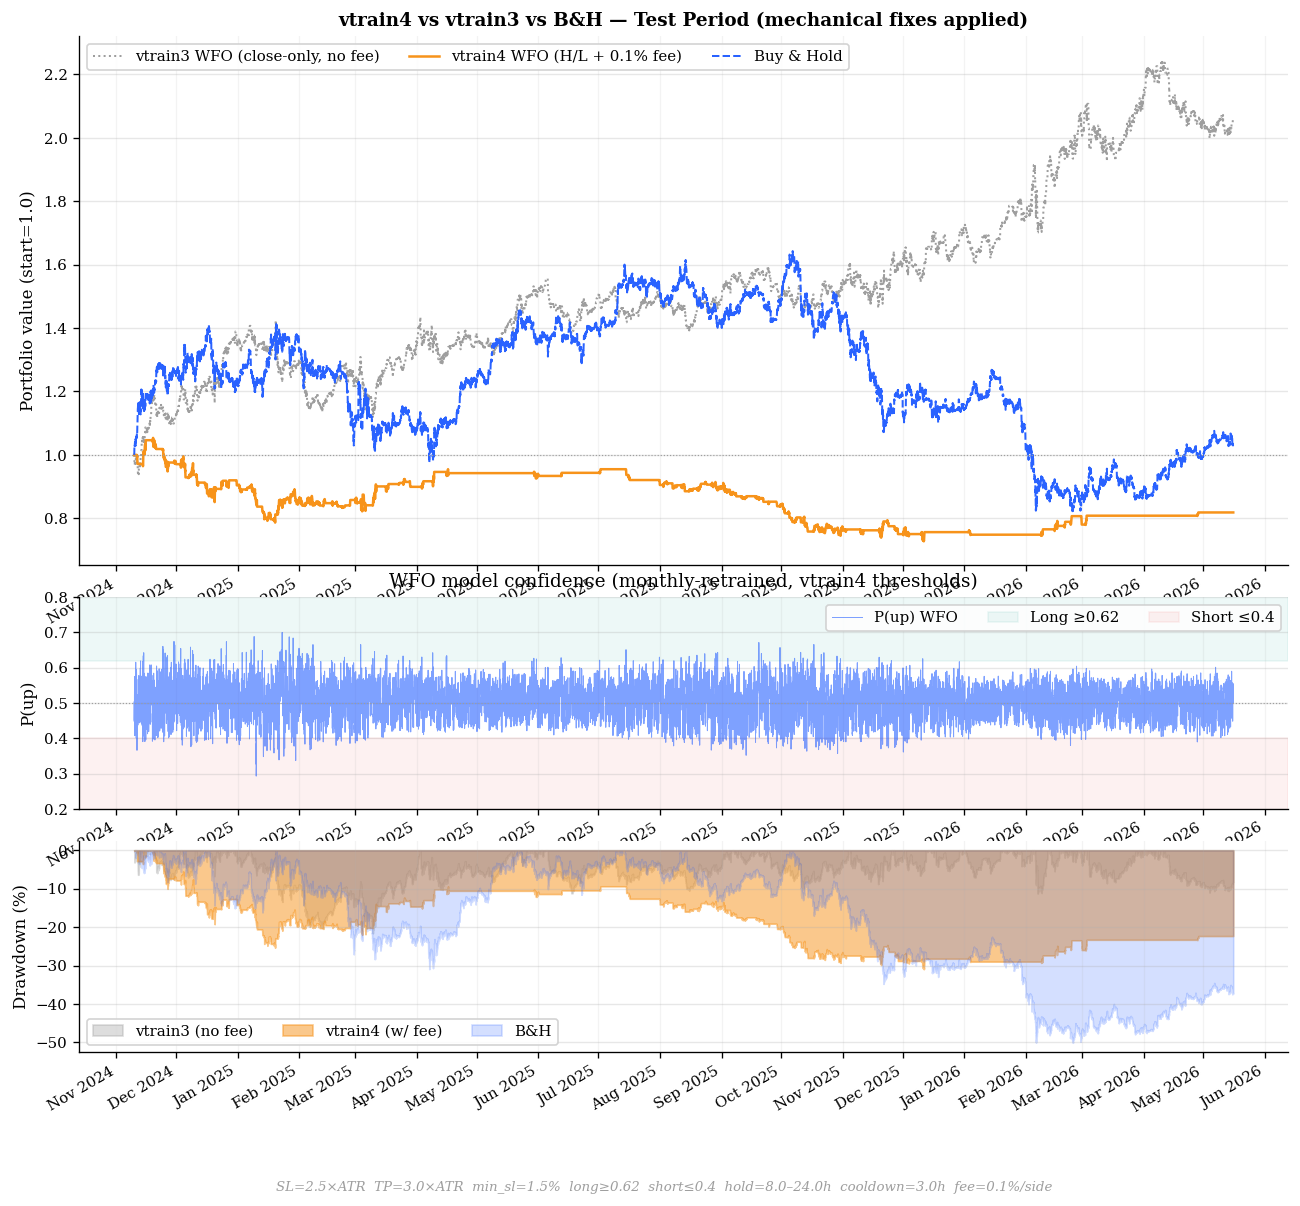

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.10})

ax = axes[0]
ax.plot(test_index, eq_v3_nofee, color=GREY,   lw=1.2, ls=':',  label='vtrain3 WFO (close-only, no fee)')
ax.plot(test_index, eq_wfo,      color=ACCENT, lw=1.5,          label=f'vtrain4 WFO (H/L + {FEE_RATE*100:.1f}% fee)')
ax.plot(test_index, bh_test,     color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title('vtrain4 vs vtrain3 vs B&H — Test Period (mechanical fixes applied)',
             fontweight='bold')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
ax.plot(test_index, wfo_probs, color=BLUE, lw=0.6, alpha=0.6, label='P(up) WFO')
ax.axhspan(best_params['long_threshold'],  1.0, alpha=0.08, color=GREEN,
           label=f'Long ≥{best_params["long_threshold"]}')
ax.axhspan(0.0, best_params['short_threshold'], alpha=0.08, color=RED,
           label=f'Short ≤{best_params["short_threshold"]}')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0.2, 0.8); ax.set_ylabel('P(up)')
ax.set_title('WFO model confidence (monthly-retrained, vtrain4 thresholds)')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[2]
pk_v3  = np.maximum.accumulate(eq_v3_nofee)
pk_v4  = np.maximum.accumulate(eq_wfo)
pk_b   = np.maximum.accumulate(bh_test)
ax.fill_between(test_index, (eq_v3_nofee - pk_v3) / (pk_v3 + 1e-12) * 100, 0,
                color=GREY,   alpha=0.35, label='vtrain3 (no fee)')
ax.fill_between(test_index, (eq_wfo - pk_v4) / (pk_v4 + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.50, label='vtrain4 (w/ fee)')
ax.fill_between(test_index, (bh_test - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE,   alpha=0.20, label='B&H')
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'SL={best_params["sl_atr_multiplier"]}×ATR  TP={best_params["tp_atr_multiplier"]}×ATR  '
    f'min_sl={best_params["min_sl"]*100:.1f}%  '
    f'long≥{best_params["long_threshold"]}  short≤{best_params["short_threshold"]}  '
    f'hold={best_params["min_hold"]}–{best_params["max_hold"]}h  '
    f'cooldown={best_params["cooldown"]}h  fee={FEE_RATE*100:.1f}%/side',
    ha='center', fontsize=8, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'grid_wfo_equity_vtrain4.png')
plt.show()

In [15]:
def full_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    an  = float((eq[-1] ** (24 * 365 / len(eq))) - 1)
    cal = an / (abs(mdd) + 1e-6)
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    pf  = 0.0
    if not tdf.empty:
        g  = tdf[tdf['pnl_pct'] > 0]['pnl_pct'].sum()
        l  = tdf[tdf['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        pf = g / (l + 1e-6)
    return {
        'Strategy':      label,
        'Total Return':  f'{eq[-1]-1:+.2%}',
        'Ann. Return':   f'{an:+.2%}',
        'Sharpe (ann.)': f'{sh:.3f}',
        'Max Drawdown':  f'{mdd:.2%}',
        'Calmar':        f'{cal:.3f}',
        'Win Rate':      f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor': f'{pf:.3f}' if pf else 'N/A',
        'Trades':        str(len(tdf)),
    }

summary = pd.DataFrame([
    full_metrics(eq_v3_nofee,  tdf_v3_nofee,  'vtrain3 WFO  (close-only SL/TP, 0% fee)'),
    full_metrics(eq_wfo,       tdf_wfo,       f'vtrain4 WFO  (H/L SL/TP, {FEE_RATE*100:.1f}% fee)'),
    full_metrics(eq_static,    tdf_static,    f'Static model (H/L SL/TP, {FEE_RATE*100:.1f}% fee)'),
    full_metrics(bh_test,      pd.DataFrame(), 'Buy & Hold'),
]).set_index('Strategy')

print('\n' + '=' * 80)
print('  FINAL TEST-SET SUMMARY — vtrain4')
print('=' * 80)
print(summary.to_string())
print('=' * 80)

# Fee impact estimate
if not tdf_v3_nofee.empty:
    n_tr     = len(tdf_v3_nofee)
    fee_drag = (1 - FEE_RATE)**( 2 * n_tr ) - 1
    print(f'\n  Estimated fee drag on vtrain3 params  ({n_tr} trades × 2 × {FEE_RATE*100:.1f}%): '
          f'{fee_drag*100:+.1f} pp  (compounded on starting equity)')


  FINAL TEST-SET SUMMARY — vtrain4
                                        Total Return Ann. Return Sharpe (ann.) Max Drawdown  Calmar Win Rate Profit Factor Trades
Strategy                                                                                                                         
vtrain3 WFO  (close-only SL/TP, 0% fee)     +106.13%     +61.33%         1.397      -21.60%   2.839    65.2%         1.185    897
vtrain4 WFO  (H/L SL/TP, 0.1% fee)           -18.15%     -12.40%        -0.674      -30.96%  -0.401    50.6%         1.132    166
Static model (H/L SL/TP, 0.1% fee)           -44.56%     -32.30%        -1.751      -48.08%  -0.672    47.2%         0.944    231
Buy & Hold                                    +3.14%      +2.07%         0.044      -50.08%   0.041      N/A           N/A      0

  Estimated fee drag on vtrain3 params  (897 trades × 2 × 0.1%): -83.4 pp  (compounded on starting equity)


In [16]:
results_path = MODELS_DIR / 'lgbm_grid_results_vtrain4.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved {len(results_df):,} grid results → {results_path}')

ret_w = np.log(np.maximum(eq_wfo[1:], 1e-12) / np.maximum(eq_wfo[:-1], 1e-12))
pk_w  = np.maximum.accumulate(eq_wfo)
ret_oos2 = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))

output = {
    'version':          'vtrain4',
    'changes_vs_vtrain3': [
        'Fix 1: SL/TP evaluated against intra-candle high/low (not close only)',
        'Fix 2: 0.1% fee per side (0.2% round-trip) applied at entry and exit',
        'Fix 3: K-Fold internal val taken from n_int bars before embargo zone, not tail of dataset',
    ],
    'fee_rate_per_side':    FEE_RATE,
    'selection_method':     'purged_kfold_trainval',
    'wfo_retrain_freq':     f'{WFO_STEP_H}h',
    'params':               best_params,
    'oos_kfold': {
        'sharpe':       round(float(ret_oos2.mean()/(ret_oos2.std(ddof=1)+1e-12)*np.sqrt(24*365)), 4),
        'total_return': round(float(eq_oos[-1] - 1), 4),
        'n_trades':     int(len(tdf_oos)),
    },
    'test_wfo': {
        'sharpe':       round(float(ret_w.mean()/(ret_w.std(ddof=1)+1e-12)*np.sqrt(24*365)), 4),
        'total_return': round(float(eq_wfo[-1] - 1), 4),
        'max_dd':       round(float(((eq_wfo-pk_w)/(pk_w+1e-12)).min()), 4),
        'n_trades':     int(len(tdf_wfo)),
    },
}

params_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain4.json'
with open(params_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved best params  → {params_path}')
print()
print(json.dumps(output, indent=2))

Saved 3,456 grid results → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_grid_results_vtrain4.csv
Saved best params  → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_best_trading_params_vtrain4.json

{
  "version": "vtrain4",
  "changes_vs_vtrain3": [
    "Fix 1: SL/TP evaluated against intra-candle high/low (not close only)",
    "Fix 2: 0.1% fee per side (0.2% round-trip) applied at entry and exit",
    "Fix 3: K-Fold internal val taken from n_int bars before embargo zone, not tail of dataset"
  ],
  "fee_rate_per_side": 0.001,
  "selection_method": "purged_kfold_trainval",
  "wfo_retrain_freq": "720h",
  "params": {
    "long_threshold": 0.62,
    "short_threshold": 0.4,
    "sl_atr_multiplier": 2.5,
    "tp_atr_multiplier": 3.0,
    "min_sl": 0.015,
    "min_hold": 8.0,
    "max_hold": 24.0,
    "cooldown": 3.0
  },
  "oos_kfold": {
    "sharpe": -0.0146,
    "total_return": -0.0472,
    "n_trades": 2096
 